In [1]:
import sys
import importlib

def install_if_missing(package, import_name=None):
    """Install a package only if it's not already installed"""
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package}...")
        !{sys.executable} -m pip install {package} -q
        print(f"{package} installed ✅")
    else:
        print(f"{package} already available ✅")

install_if_missing("datasets")
install_if_missing("tqdm")
install_if_missing("ipywidgets")

datasets already available ✅
tqdm already available ✅
ipywidgets already available ✅


In [25]:
# Imports
import os

import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam

from torchvision import transforms
from datasets import load_dataset
from tqdm import tqdm

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version : 2.3.1
Device          : cpu


In [3]:
# Load dataset
dataset = load_dataset("jiovine/pixel-art-nouns")['train']

print(f"Number of samples: {len(dataset)}")
print(f"Features: {dataset.features}")

Number of samples: 49859
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}


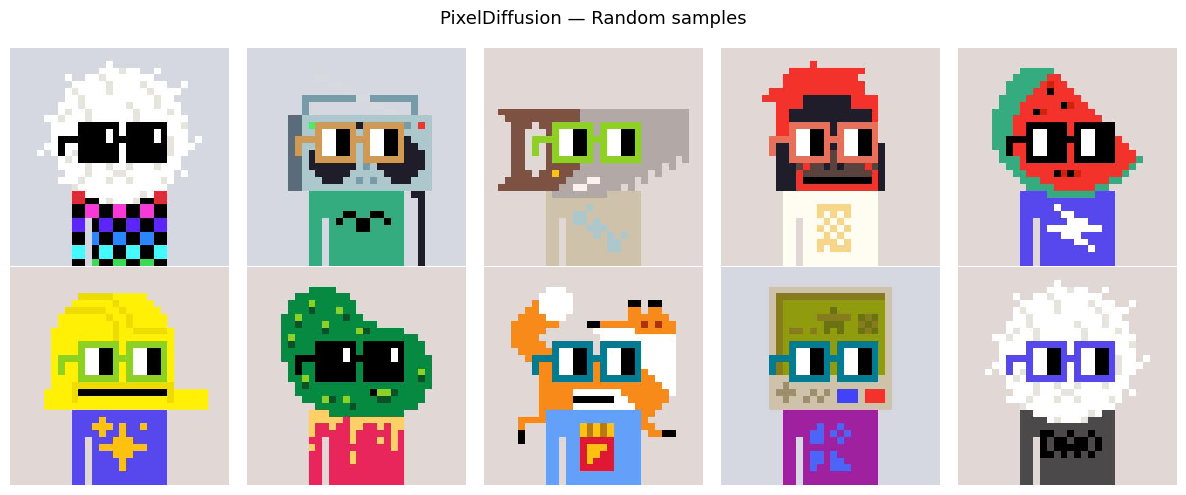

In [4]:
# Display random pixel art from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

indices = random.sample(range(len(dataset)), 10)

for i, ax in enumerate(axes):
    sample = dataset[indices[i]]
    img = sample['image']
    
    ax.imshow(img, interpolation='nearest')
    ax.axis('off')

plt.suptitle("PixelDiffusion — Random samples", fontsize=13)
plt.tight_layout()
plt.show()

# Tokenization
Let's build a custom tokenizer

In [5]:
# Extract all the text from the dataset
texts = [sample['text'] for sample in dataset]

In [6]:
# Definition of the tokenizer
def tokenize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s-]', '', text)
    text = text.replace('-', ' - ')
    return text.split()

print(tokenize_text(texts[0]))

['a', 'character', 'with', 'square', 'black', 'glasses', 'a', 'hotdog', '-', 'shaped', 'head', 'and', 'a', 'peachy', '-', 'colored', 'body', 'on', 'a', 'warm', 'background']


In [7]:
# Build the vocab
word_counts = Counter()
for text in texts:
    word_counts.update(tokenize_text(text))

special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']

vocab = special_tokens + [word for word, count in word_counts.most_common()]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Vocabulary size : {len(vocab)}")
print(f"Most common words : {word_counts.most_common(10)}")

Vocabulary size : 316
Most common words : [('a', 199436), ('-', 100538), ('and', 58531), ('with', 52032), ('character', 49859), ('square', 49859), ('shaped', 49859), ('head', 49859), ('colored', 49859), ('body', 49859)]


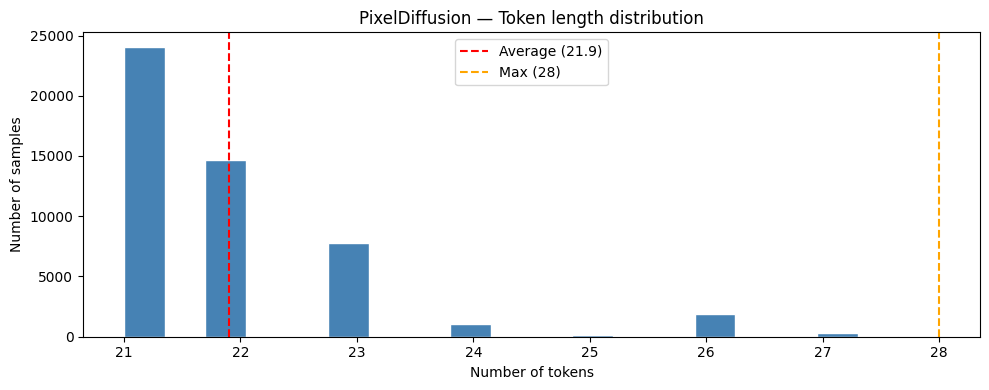

In [8]:
# Let's see the token length distribution
token_lengths = [len(tokenize_text(text)) for text in texts]

avg_len = sum(token_lengths) / len(token_lengths)

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=20, color='steelblue', edgecolor='white')
plt.axvline(avg_len, color='red', linestyle='--', label=f'Average ({avg_len:.1f})')
plt.axvline(max(token_lengths), color='orange', linestyle='--', label=f'Max ({max(token_lengths)})')
plt.xlabel("Number of tokens")
plt.ylabel("Number of samples")
plt.title("PixelDiffusion — Token length distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Encode and decode function
MAX_LEN = 24 + 2

def encode(text, max_len=MAX_LEN):
    tokens = tokenize_text(text)
    ids = [word2idx['<BOS>']]
    ids += [word2idx.get(t, word2idx['<UNK>']) for t in tokens]
    ids += [word2idx['<EOS>']]
    # Pad or truncate
    ids = ids[:max_len]
    ids += [word2idx['<PAD>']] * (max_len - len(ids))
    return ids

def decode(ids):
    words = [idx2word[i] for i in ids 
             if i not in [word2idx['<PAD>'], word2idx['<BOS>'], word2idx['<EOS>']]]
    return ' '.join(words)

In [10]:
sample_text = texts[0]
encoded = encode(sample_text)
decoded = decode(encoded)

print(f"\nOriginal : {sample_text}")
print(f"Encoded  : {encoded}")
print(f"Decoded  : {decoded}")


Original : a character with square black glasses, a hotdog-shaped head and a peachy-colored body on a warm background
Encoded  : [2, 4, 8, 7, 9, 22, 16, 4, 138, 5, 10, 11, 6, 4, 31, 5, 12, 13, 14, 4, 17, 15, 3, 0, 0, 0]
Decoded  : a character with square black glasses a hotdog - shaped head and a peachy - colored body on a warm background


# Noise Scheduler - Linear DDPM

## Forward Process

Add noise between the image $x_{t-1}$ and $x_t$. As we're using a Gaussian distribution, the relation is:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t} \cdot x_{t-1}, \beta_t I)$$

Where $\beta_t$ controls the progressive addition of noise.

Then, we can obtain $x_t$ by sampling:

$$x_t = \sqrt{1-\beta_t} \cdot x_{t-1} + \sqrt{\beta_t} \cdot \varepsilon$$

Where $\varepsilon \sim \mathcal{N}(0, I)$ is a sample of pure random Gaussian noise. It's a tensor of the 
same shape as $x_t$, independent at each timestep.

From the first relation, we can deduce : 

$$q(x_t|x_0) = \mathcal{N}(x_t,\sqrt{\bar{\alpha_t}}x_0,(1-\bar{\alpha_t}) I)$$

Where :
 - $\alpha_t = 1 - \beta_t$
 - $\bar{\alpha_t} = \Pi^t_{s=1} \alpha_s$

Then, we can obtain $x_t$ by sampling :

$$x_t = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \varepsilon$$

In [11]:
# Parameters
T = 1000 # if T is big, we can train the model to inverse each transformation
beta_start = 1e-4
beta_end = 0.02

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = (1 - betas).to(device)
alpha_bars = torch.cumprod(alphas, dim=0).to(device)

print(f"Running on : {device}")

Running on : cpu


In [12]:
# Let's create the function that add noise
def add_noise(x0,t):
    # Compute the noise
    noise = torch.randn_like(x0)
    # Get the wanted alpha bar
    ab = alpha_bars[t].view(-1, 1, 1, 1)
    # Compute xt
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    return x_t, noise

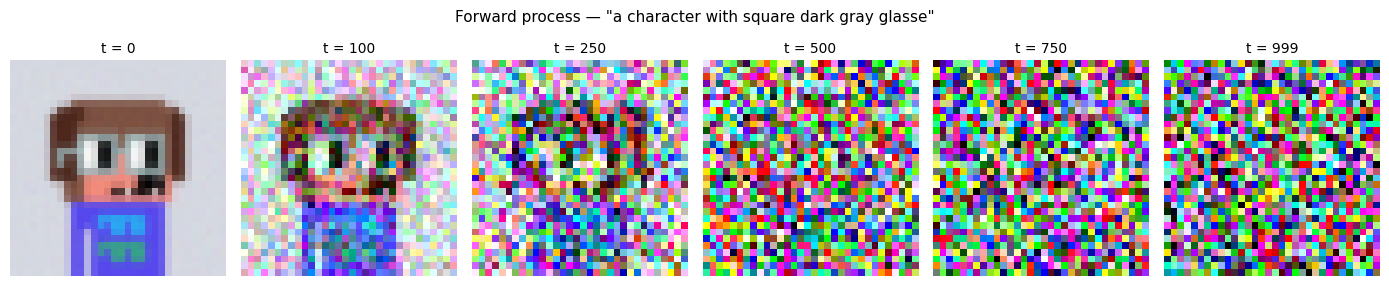

In [13]:
# Load one sample
idx = random.randint(0, len(dataset) - 1)
sample = dataset[idx]
img = sample['image']
label  = sample['text']

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

x0 = transform(img).unsqueeze(0).to(device)

# Different timesteps
timesteps = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(timesteps), figsize=(14, 3))

for ax, t in zip(axes, timesteps):
    t_tensor    = torch.tensor([t]).to(device)  # ← send to device
    x_t, _      = add_noise(x0, t_tensor)

    # Denormalize for display [-1,1] → [0,1]
    img_display = (x_t.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) / 2  # ← .cpu() before .numpy()
    img_display = np.clip(img_display, 0, 1)

    ax.imshow(img_display, interpolation='nearest')
    ax.set_title(f't = {t}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'Forward process — "{label[:40]}"', fontsize=11)
plt.tight_layout()
plt.show()

# DDPM

In the ddpm model, we are looking to predict the denoising step

## Embedding
Here we choose a sinusoidal embedding as it requires no parameters to learn (unlike a learned embedding). Each timestep has a unique signature, and the distances between different timesteps are geometrically coherent.

$$PE(t, 2i) = \sin\left(\frac{t}{10000^{2i/d}}\right) \qquad PE(t, 2i+1) = \cos\left(\frac{t}{10000^{2i/d}}\right)$$

- $t \in \{0, ..., T-1\}$ : the current timestep
- $i \in \{0, ..., d/2 - 1\}$ : the index of the embedding dimension
- $d$ : the total dimension of the embedding vector (e.g. $d = 128$)
- $10000$ : a large constant that controls the frequency range of the sinusoids
- $PE(t, 2i)$ : the sine component at even dimension $2i$
- $PE(t, 2i+1)$ : the cosine component at odd dimension $2i+1$

Example : if $d=6$, then we will have the following vector for a timestep $t$ :

$$PE(t) = \left[ \sin\left(\frac{t}{10000^{0/6}}\right), \cos\left(\frac{t}{10000^{0/6}}\right), \sin\left(\frac{t}{10000^{2/6}}\right), \cos\left(\frac{t}{10000^{2/6}}\right), \sin\left(\frac{t}{10000^{4/6}}\right), \cos\left(\frac{t}{10000^{4/6}}\right) \right]$$

For small $i$, the frequency is high, allowing the model to capture fine-grained differences between close timesteps. And, for large $i$, the frequency is low, and it allows the model to capture global structure across all timesteps.

In [14]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

        # At this point we could implement on top of the sinusoide embedding a small MLP to project better

    def sinusoidal_embedding(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        args  = t[:, None].float() * freqs[None]
        emb   = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb

    def forward(self,t):
        return self.sinusoidal_embedding(t)

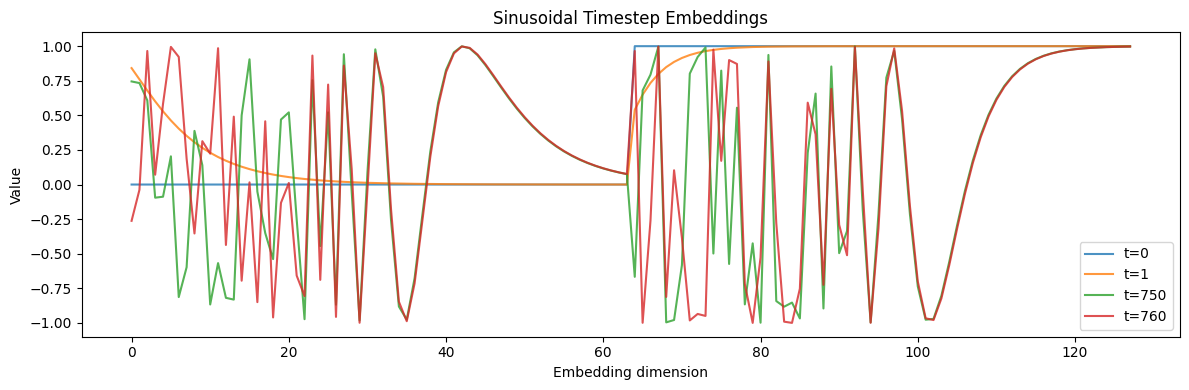

In [15]:
te = TimestepEmbedding(dim=128)
timesteps = [0, 1, 750, 760]

with torch.no_grad():
    emb = te(torch.tensor(timesteps))
plt.figure(figsize=(12, 4))
for i, t in enumerate(timesteps):
    plt.plot(emb[i].numpy(), label=f't={t}', alpha=0.8)

plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.title("Sinusoidal Timestep Embeddings")
plt.legend()
plt.tight_layout()
plt.show()

## U-Net

### ResBlock
The aim of the residual block is to find a solution against the gradient vanishing problem. In a deep network, the gradient becomes smaller and smaller as it propagates back through the layers, making the first layers unable to learn. The residual connection solves this by  adding a shortcut that allows the gradient to flow directly through the network, bypassing the convolutions :

$$\text{output} = F(x) + x$$

Where $F(x)$ is the result of the convolutions and $x$ is the original input (the skip connection).

In our DDPM, each ResBlock also receives the timestep embedding $t$ which is injected in the middle of the block, allowing the network to adapt its behavior depending on the current noise level.

ResBlock Scheme : 

```
Input x  (in_channels)
    │
    ▼
block1 : in_channels  → out_channels
    │
    + t_emb
    │
    ▼
block2 : out_channels → out_channels
    │
    + skip
    │
    ▼
Output (out_channels)
```

In [16]:
class ResBlock(nn.Module):
    def __init__(self, in_channels:int,out_channels:int,emb_dim:int):
        """
        in_channels : number of input channels
        out_channels : number of output channels
        emb_dim : dimension of the timestep embedding
        """

        super().__init__()

        # First block
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels), #split channels into group of 8
            nn.SiLU(),
            nn.Conv2d(in_channels,out_channels, kernel_size=3,padding=1)
        )

        # Embedding projection
        # We need to project the embedding in order to be in the same space while adding
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_channels)
        )

        # Second block
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels,out_channels, kernel_size=3,padding=1)
        )

        # Skip connection
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) #too match if different
        else:
            self.skip = nn.Identity()

    def forward(self,x,t_emb):
        """
        x     : (B, in_channels, H, W)
        t_emb : (B, emb_dim)
        """

        # First block
        # (B, out_channels, H, W)
        h = self.block1(x)

        # Add time step embedding
        # (B, emb_dim)
        t = self.time_proj(t_emb)
        # (B, out_channels)

        # Add by broadcasting
        h = h + t[:, :, None, None]

        # Second block
        # (B, out_channels, H, W)
        h = self.block2(h)

        # Skip connection
        return h + self.skip(x)

In [17]:
# Test if ResBlock is working
emb_dim = 128
te = TimestepEmbedding(dim=emb_dim)
resblock = ResBlock(in_channels=32, out_channels=64, emb_dim=emb_dim)

x = torch.randn(4, 32, 32, 32)
t = torch.randint(0, T, (4,))
t_emb = te(t)

output = resblock(x, t_emb)

print(f"Input  shape : {x.shape}")
print(f"Output shape : {output.shape}")
print(f"ResBlock params : {sum(p.numel() for p in resblock.parameters()):,}")

Input  shape : torch.Size([4, 32, 32, 32])
Output shape : torch.Size([4, 64, 32, 32])
ResBlock params : 65,984


### Self-Attention Block

While the ResBlock processes the image locally (3x3 convolution), the Self-Attention block gives the network a global view, each pixel can attend to every other pixel in the feature map.

Each pixel is projected into three vectors : a Query, a Key, and a Value :

$$Q = W_Q \cdot x \qquad K = W_K \cdot x \qquad V = W_V \cdot x$$

The attention scores are computed as a scaled dot-product between queries and keys :

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Where $d_k$ is the dimension of the head. The $\sqrt{d_k}$ scaling prevents the dot products from growing too large before the softmax.

A residual connection is also added, following the same principle as in the ResBlock :

$$\text{output} = \text{Attention}(Q, K, V) + x$$

In our DDPM, the Self-Attention is placed at the bottleneck, where the global context is most needed and the computational cost remains low.

In [18]:
class SelfAttention(nn.Module):
    def __init__(self, channels:int,n_heads:int=4):
        """
        channels : number of input/output channels
        n_heads  : number of attention heads
        """
        super().__init__()
        assert channels % n_heads == 0

        self.channels = channels
        self.n_heads = n_heads
        self.head_dim = channels // n_heads

        # Normalization
        self.norm = nn.GroupNorm(8, channels)

        # Q,K,V Linear
        self.qkv = nn.Linear(channels, channels * 3)
        self.output = nn.Linear(channels,channels)

    def forward(self,x):
        """
        x : (B, C, H, W)
        """

        B,C,H,W = x.shape

        # Norm
        h = self.norm(x)

        # Flatten
        h = h.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)

        # Compute Q, K, V
        qkv = self.qkv(h) # (B, H*W, 3*C)
        q,k,v = qkv.chunk(3, dim=-1) # 3*(B, H*W, C)

        # At this point, the differents head are inside q,k,v s we need to split thoses matrix depending on n_heads
        def split_heads(t):
                    return t.view(B, H * W, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, H*W, head_dim)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Dot-product attention
        scale  = self.head_dim ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale  # (B, n_heads, H*W, H*W)
        attn   = torch.softmax(scores, dim=-1) # (B, n_heads, H*W, H*W)

        # Weighted sum of values
        out = torch.matmul(attn, v) # (B, n_heads, H*W, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous()  # (B, H*W, n_heads, head_dim)
        out = out.view(B, H * W, C) # (B, H*W, C)

        # Output projection
        out = self.output(out) # (B, H*W, C)

        # Reshape
        out = out.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Return with residual
        return out + x    
        

In [19]:
# Test is the attention block is working
attn = SelfAttention(channels=64, n_heads=4)

x = torch.randn(4, 64, 4, 4)
output = attn(x)

print(f"Input  shape : {x.shape}")       # (4, 64, 4, 4)
print(f"Output shape : {output.shape}")  # (4, 64, 4, 4)
print(f"Attention params : {sum(p.numel() for p in attn.parameters()):,}")

Input  shape : torch.Size([4, 64, 4, 4])
Output shape : torch.Size([4, 64, 4, 4])
Attention params : 16,768


### U-Net

#### Encoder

The encoder progressively compresses the spatial resolution while increasing the number of channels. Starting from the initial feature map (32x32, 32 channels), each level applies two ResBlocks followed by a strided convolution that halves the resolution :

$$x_{l+1} = \text{Downsample}(\text{ResBlock}_2(\text{ResBlock}_1(x_l, t), t))$$

At each level, the number of channels doubles : $32 \rightarrow 64 \rightarrow 128$, allowing the network to exchange spatial resolution for richer feature representations. The skip connections $\{s_1, s_2, s_3\}$ are saved at each level before downsampling, preserving the fine-grained spatial information that will be reinjected in the decoder.

---

#### Bottleneck

The bottleneck is the deepest part of the U-Net, operating at the lowest resolution (4x4 in our case). At this point, the image has been compressed into a rich abstract representation : each of the 128 channels encodes high-level semantic information rather than raw pixel values.

It is composed of three blocks :

$$\text{Bottleneck}(x, t) = \text{ResBlock}_2(\text{Attention}(\text{ResBlock}_1(x, t)), t)$$

The two ResBlocks refine the feature representation while the Self-Attention block in the middle allows every spatial position to exchange information globally. This is the only place in the network where a pixel at position $(i, j)$ can directly influence a pixel at position $(i', j')$.

The bottleneck is also where the network reasons about the global structure of the image : what is the overall composition, the dominant colors, the background; before the decoder starts reconstructing the spatial details level by level.

---

#### Decoder

The decoder is the symmetric counterpart of the encoder it progressively restores the spatial resolution while decreasing the number of channels. At each level, a transposed convolution doubles the resolution, followed by the concatenation of the corresponding skip connection from the encoder :

$$x_{l-1} = \text{ResBlock}_2(\text{ResBlock}_1(\text{cat}(\text{Upsample}(x_l), s_l), t), t)$$

The skip connections are crucial here, they reintroduce the fine spatial details that were lost during downsampling, allowing the decoder to reconstruct sharp and precise outputs. Without them, the decoder would have to hallucinate all spatial details from the bottleneck alone.

The channel progression follows the reverse path : $128 \rightarrow 64 \rightarrow 32$, until the final convolution projects back to the original 3 channels to produce the predicted noise $\hat{\varepsilon}$ of the same shape as the input image.

In [20]:
class UNet(nn.Module):
    def __init__(
        self, 
        in_channels:int=3,
        base_channels:int=32,
        channel_mults = (1,2,4),
        n_heads = 4,
        emb_dim =128
    ):
        super().__init__()

        self.emb_dim = emb_dim
        channels = [base_channels * i for i in channel_mults]

        # Timestep embedding
        self.time_emb = TimestepEmbedding(emb_dim)

        # init conv
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)


        ###########
        # Encoder #
        ###########

        # To increase the number of channels and learn multiple features
        self.encoder_blocks = nn.ModuleList()
        # To reduce the size of the input and see the features more precisely/largelly
        self.downsamplers = nn.ModuleList()

        in_ch = base_channels
        for out_ch in channels:
            self.encoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch,  out_ch, emb_dim), # Changes the channel dimension
                ResBlock(out_ch, out_ch, emb_dim), # Work in the same space -> extracts more complex patterns
            ]))
            self.downsamplers.append(
                nn.Conv2d(out_ch, out_ch, kernel_size=4, stride=2, padding=1)
            )
            in_ch = out_ch

        ##############
        # Bottleneck #
        ##############
        mid_ch = channels[-1]
        self.bottleneck = nn.ModuleList([
            ResBlock(mid_ch, mid_ch, emb_dim),
            SelfAttention(mid_ch, n_heads),
            ResBlock(mid_ch, mid_ch, emb_dim),
        ])

        ###########
        # Decoder #
        ###########
        # Reduce the number of channels and features
        self.decoder_blocks = nn.ModuleList()
        # Increase the size of the value inside the bottlenck
        self.upsamplers      = nn.ModuleList()

        for out_ch in reversed(channels):
            self.upsamplers.append(
                nn.ConvTranspose2d(in_ch, in_ch, kernel_size=4, stride=2, padding=1)
            )
            self.decoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch + out_ch, out_ch, emb_dim),   # +out_ch for skip connection
                ResBlock(out_ch, out_ch, emb_dim),
            ]))
            in_ch = out_ch

        # Final conv that predict the noise
        self.final = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)
        )
        
    def forward(self, x, t):
        """
        x : (B, 3, 32, 32) noisy image
        t : (B,)            timestep
        returns predicted noise ε (B, 3, 32, 32)
        """

        # Timestep embedding
        t_emb = self.time_emb(t) # (B, emb_dim)

        x = self.init_conv(x) 

        ### Encoder ###
        skips = []
        for (res1, res2), down in zip(self.encoder_blocks, self.downsamplers):
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock
            skips.append(x)
            x = down(x) # DownSample

        ### Bottleneck ###
        res1, attn, res2 = self.bottleneck
        x = res1(x, t_emb)
        x = attn(x)
        x = res2(x, t_emb)

        ### Decoder ###
        for (res1, res2), up, skip in zip(self.decoder_blocks, self.upsamplers, reversed(skips)):
            x = up(x) # UpSample
            x = torch.cat([x, skip], dim=1) # Add the residual
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock

        # Final conv
        return self.final(x)



In [21]:
model = UNet()

# Fake batch
x = torch.randn(8, 3, 32, 32)
t = torch.randint(0, T, (8,))

with torch.no_grad():
    output = model(x, t)

print(f"Input  shape : {x.shape}")
print(f"Output shape : {output.shape}")
print(f"Total params : {sum(p.numel() for p in model.parameters()):,}")

Input  shape : torch.Size([8, 3, 32, 32])
Output shape : torch.Size([8, 3, 32, 32])
Total params : 3,502,883


# Training loop

In [22]:
# Load the dataset
class PixelArtDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, image_size:32):
        self.dataset   = hf_dataset
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img    = self.transform(sample['image'])
        return img

image_size = 32
train_dataset = PixelArtDataset(dataset,image_size)
train_loader  = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle    = True,
    num_workers= 0
)

print(f"Dataset size : {len(train_dataset)}")
print(f"Batches per epoch : {len(train_loader)}")

Dataset size : 49859
Batches per epoch : 780


In [26]:
# Confing
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PRETRAINED = "pixeldiffusion_epoch_30.pt"  # None to train from scratch
CHECKPOINT_DIR = "./"
epochs = 100
T = 1000
lr = 2e-4

print(f"Training on : {device}")

# Model setup
model = UNet().to(device)
optimizer = Adam(model.parameters(), lr=lr)
start_epoch = 0
losses = []

# AMP Scaler
#scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

# Load pretrained if available
if PRETRAINED is not None:
    checkpoint_path = os.path.join(CHECKPOINT_DIR, PRETRAINED)
    try:
        checkpoint  = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        start_epoch = checkpoint['epoch'] + 1
        losses      = checkpoint.get('losses', [])
        print(f"Resuming from epoch {start_epoch} | Last loss : {checkpoint['loss']:.6f}")
    except FileNotFoundError:
        print(f"No checkpoint found at {checkpoint_path} — training from scratch")
else:
    print("Training from scratch")

# Load multi-GPU id available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)     

for epoch in range(start_epoch,epochs):
    epoch_loss = 0.0
    model.train()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)

    for batch in progress_bar:

        x0 = batch.to(device) # (B, 3, 32, 32)
        B  = x0.shape[0]

        # Sample random timestep
        t  = torch.randint(0, T, (B,), device=device)  # (B,)

        # Add noise
        x_t, noise = add_noise(x0, t) # (B, 3, 32, 32)

        # AMP forward pass
        #with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            # Predict noise 
            #noise_pred = model(x_t, t) # (B, 3, 32, 32)
            # Loss
            #loss = F.mse_loss(noise_pred, noise)

        # AMP backward pass
        #optimizer.zero_grad()
        # Scale gradients
        #scaler.scale(loss).backward()
        # Unscale + optimizer step
        #scaler.step(optimizer)
        #scaler.update()

        # Prediction & Loss 
        noise_pred = model(x_t, t)
        loss = F.mse_loss(noise_pred, noise)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=f"{loss.item():.6f}")

    # Print
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    if epoch % 10 == 0:
        torch.save({
            'epoch' : epoch,
            'model_state' : model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'loss' : avg_loss,
        }, f"pixeldiffusion_epoch_{epoch}.pt")
        print(f"Epoch {epoch:4d} / {epochs} | Loss : {avg_loss:.6f} | Model saved")
    else:
        print(f"Epoch {epoch:4d} / {epochs} | Loss : {avg_loss:.6f}")

plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PixelDiffusion — Training Loss")
plt.tight_layout()
plt.show()

Training on : cpu
Resuming from epoch 31 | Last loss : 0.010533


KeyboardInterrupt: 